# **GAIA GraL Catalogue (2026 Ducourant et al.)**

---

VizieR: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/A+A/707/A345 \
Paper: https://doi.org/10.1051/0004-6361/202558049

In [39]:
#> imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#> data imports
import astropy.io.fits as fits
from astropy.table import Table

#> astropy
from astropy.coordinates import SkyCoord
import astropy.units as u

### ***Loading in fits***
---

Table Reference:

In [40]:
#> loading in data
file = './tablea1.fit'

#> getting table
table = Table.read(file, hdu=1)
df = table.to_pandas()

#> reducing to quads
df = df[ df['Type'] == b'Quad  ' ]

#> binary to normal strings
for key in df.keys():
    try: df[key] = [ x.decode('utf-8') for x in df[key] ]
    except: continue

#> sorting based on name and component
df = df.sort_values(['Name', 'Comp']).reset_index(drop=True)

#> printing
df.describe()
df

### THE ERRORS HERE CAN BE IGNORED ###

,TimeDelay,Name,Comp,RAJ2000,DEJ2000,Type,MaxSep,rpos,Author,Date,...,RACodeg,e_RACodeg,DECodeg,inDR3,GaiaDR3,RAGdeg,e_RAGdeg,DEGdeg,e_DEGdeg,recno
0,b'*',2MASSJ11344050-2103230,A,11 34 40.5845,-21 03 23.163,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,0.0,0.0,1,3541826024524572544,173.669102,0.0663,-21.056434,0.0503,568
1,b'*',2MASSJ11344050-2103230,B,11 34 40.6366,-21 03 21.408,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,0.0,0.0,1,3541826024526317568,173.669319,0.0613,-21.055947,0.0466,569
2,b'*',2MASSJ11344050-2103230,C,11 34 40.4454,-21 03 23.936,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,0.0,0.0,1,3541826024526317312,173.668522,0.0650,-21.056649,0.0494,565
3,b'*',2MASSJ11344050-2103230,D,11 34 40.4954,-21 03 21.797,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,0.0,0.0,1,3541826024524572288,173.668731,0.2403,-21.056055,0.2090,566
4,b'*',2MASSJ11344050-2103230,G,11 34 40.5308,-21 03 22.384,Quad,3.682,HST,Lucey,2018,...,0.0,0.0,0.0,0,0,0.000000,0.0000,0.000000,0.0000,567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,b'*',WISE025942.9-163543,A,02 59 42.9100,-16 35 43.300,Quad,1.575,Gaia_DR3,Schechter,2018,...,0.0,0.0,0.0,1,5153828508862119040,44.928792,0.3252,-16.595361,0.3429,153
370,b'*',WISE025942.9-163543,B,02 59 42.8879,-16 35 42.423,Quad,1.575,Gaia_DR3,Schechter,2018,...,0.0,0.0,0.0,1,5153828504567283072,44.928699,0.3104,-16.595118,0.3123,152
371,b'*',WISE025942.9-163543,C,02 59 42.8076,-16 35 42.738,Quad,1.575,Gaia_DR3,Schechter,2018,...,0.0,0.0,0.0,1,5153828508862118912,44.928365,0.4706,-16.595205,0.5204,149
372,b'*',WISE025942.9-163543,D,02 59 42.8601,-16 35 43.690,Quad,1.575,HST,Schechter,2018,...,0.0,0.0,0.0,0,0,0.000000,0.0000,0.000000,0.0000,150


In [41]:
#> converts sexa to degree
def sexagesimal_to_deg(ra, dec):
    try:
        c = SkyCoord(str(ra), str(dec), unit=(u.hourangle, u.deg))
        return c.ra.deg, c.dec.deg
    except Exception:
        return np.nan, np.nan

#> converting RAJ2000 and DEJ2000
converted = df.apply(lambda row: sexagesimal_to_deg(row['RAJ2000'], row['DEJ2000']), axis=1)
df['RAJ2000_deg'] = [x[0] for x in converted]
df['DEJ2000_deg'] = [x[1] for x in converted]

## ***Comparing 'Best Coord' Publication Values***
---
When the 'best coordinates' (key==rpos) is from the original publication, checking to see if RAJ2000, DEJ2000 are the same as RApdeg, DEpdeg.

In [42]:
#> 'best coords' == Publication 
pub = df[df['rpos'] == 'Publication'].copy()

#> comparing 'best coords' to Publication
pub['RA_diff_deg'] = pub['RAJ2000_deg'] - pub['RApdeg']
pub['DE_diff_deg'] = pub['DEJ2000_deg'] - pub['DEpdeg']
pub['RA_diff_arcsec'] = pub['RA_diff_deg'] * 3600
pub['DE_diff_arcsec'] = pub['DE_diff_deg'] * 3600

#> finding differences
threshold = 1e-3
issues = pub[(pub['RA_diff_arcsec'].abs() >= threshold) | (pub['DE_diff_arcsec'].abs() >= threshold)]
issues[['Name', 'Comp', 'RAJ2000', 'RAJ2000_deg', 'RApdeg', 'RA_diff_deg', 'RA_diff_arcsec',
        'DEJ2000', 'DEJ2000_deg', 'DEpdeg', 'DE_diff_deg', 'DE_diff_arcsec']]

,Name,Comp,RAJ2000,RAJ2000_deg,RApdeg,RA_diff_deg,RA_diff_arcsec,DEJ2000,DEJ2000_deg,DEpdeg,DE_diff_deg,DE_diff_arcsec
44,B1555+375,A,15 57 11.9450,239.299771,239.299750,0.000021,0.0750,+37 21 35.934,37.359982,37.360000,-0.000018,-0.06600
45,B1555+375,B,15 57 11.9389,239.299745,239.299708,0.000037,0.1335,+37 21 35.983,37.359995,37.360000,-0.000005,-0.01700
46,B1555+375,C,15 57 11.9103,239.299626,239.299625,0.000001,0.0045,+37 21 35.906,37.359974,37.359972,0.000002,0.00600
47,B1555+375,D,15 57 11.9317,239.299715,239.299708,0.000007,0.0255,+37 21 35.586,37.359885,37.359889,-0.000004,-0.01400
48,B1555+375,G,15 57 11.9312,239.299713,239.299647,0.000066,0.2370,+37 21 35.694,37.359915,37.359932,-0.000017,-0.06084
49,B1608+656,A,16 09 13.9861,242.308275,242.308150,0.000126,0.4530,+65 32 28.884,65.541357,65.541389,-0.000032,-0.11500
271,PSJ042913.17+142840.9,B,04 29 13.1676,67.304865,67.304746,0.000119,0.4284,+14 28 41.005,14.478057,14.477902,0.000155,0.55780
334,SDSSJ2222+2745,A,22 22 09.0451,335.537688,335.537667,0.000021,0.0765,+27 45 37.936,27.760538,27.760528,0.000010,0.03600


**There appears to be an issue with transfering the publication astrometry (XXpdeg) to the best coordinate values (XXJ2000) for these components.** For point-source astrometry, it would be best to have any error be below 1 mas or 2.7e-7 degrees (the best possible astrometric uncertainty currently), which is the threshold I apply here. I am not sure if XXJ2000 or XXpdeg is correct here, only that there is a difference between the two.

## ***Getting Single Deflectors***
---
For our analysis we only care about single galaxy deflectors with four image positions and the galaxy position. Filtering the data.

In [43]:
#> new dataframe
gals = pd.crosstab(df['Name'], df['Comp']).reset_index()

#> all possible components
def_comps = ['G ', 'G1', 'G2', 'G3', 'G4', 'G5']
img_comps = ['A ', 'A1', 'A2', 'B ', 'C ', 'D ', 'E ', 'F ']

#> adds missing components if needed
for col in (def_comps + img_comps):
    if col not in gals.columns:
        gals[col] = 0

#> gets counts
gals['n_defs'] = gals[def_comps].sum(axis=1)
gals['n_ims'] = gals[img_comps].sum(axis=1)

#> one deflector quads
oneg_quads = gals[(gals['n_defs'] == 1) & (gals['n_ims'] == 4)].reset_index(drop=True)
oneg_quads

Comp,Name,A,A1,A2,B,C,D,E,F,G,G1,G2,G3,G4,G5,S,n_defs,n_ims
0,2MASSJ11344050-2103230,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
1,2MASXJ01471020+4630433,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
2,ATLASJ2344-3056,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
3,B0712+472,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
4,B1422+231,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
5,B1555+375,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
6,B1608+656,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
7,COSMOS5921+0638,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
8,DESJ0029-3814,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4
9,DESJ0053-2012,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,4


## ***Getting Relative Positions***
---
Converting the absolute RA and DEC to relative RA and DEC with respect to the single deflector (G).

In [44]:
#> getting all one deflector components from main dataframe
comps = df[df['Name'].isin(oneg_quads['Name'])].reset_index(drop=True)
comps

,TimeDelay,Name,Comp,RAJ2000,DEJ2000,Type,MaxSep,rpos,Author,Date,...,DECodeg,inDR3,GaiaDR3,RAGdeg,e_RAGdeg,DEGdeg,e_DEGdeg,recno,RAJ2000_deg,DEJ2000_deg
0,b'*',2MASSJ11344050-2103230,A,11 34 40.5845,-21 03 23.163,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,1,3541826024524572544,173.669102,0.0663,-21.056434,0.0503,568,173.669102,-21.056434
1,b'*',2MASSJ11344050-2103230,B,11 34 40.6366,-21 03 21.408,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,1,3541826024526317568,173.669319,0.0613,-21.055947,0.0466,569,173.669319,-21.055947
2,b'*',2MASSJ11344050-2103230,C,11 34 40.4454,-21 03 23.936,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,1,3541826024526317312,173.668522,0.0650,-21.056649,0.0494,565,173.668522,-21.056649
3,b'*',2MASSJ11344050-2103230,D,11 34 40.4954,-21 03 21.797,Quad,3.682,Gaia_DR3,Lucey,2018,...,0.0,1,3541826024524572288,173.668731,0.2403,-21.056055,0.2090,566,173.668731,-21.056055
4,b'*',2MASSJ11344050-2103230,G,11 34 40.5308,-21 03 22.384,Quad,3.682,HST,Lucey,2018,...,0.0,0,0,0.000000,0.0000,0.000000,0.0000,567,173.668878,-21.056218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,b'*',WISE025942.9-163543,A,02 59 42.9100,-16 35 43.300,Quad,1.575,Gaia_DR3,Schechter,2018,...,0.0,1,5153828508862119040,44.928792,0.3252,-16.595361,0.3429,153,44.928792,-16.595361
241,b'*',WISE025942.9-163543,B,02 59 42.8879,-16 35 42.423,Quad,1.575,Gaia_DR3,Schechter,2018,...,0.0,1,5153828504567283072,44.928699,0.3104,-16.595118,0.3123,152,44.928700,-16.595117
242,b'*',WISE025942.9-163543,C,02 59 42.8076,-16 35 42.738,Quad,1.575,Gaia_DR3,Schechter,2018,...,0.0,1,5153828508862118912,44.928365,0.4706,-16.595205,0.5204,149,44.928365,-16.595205
243,b'*',WISE025942.9-163543,D,02 59 42.8601,-16 35 43.690,Quad,1.575,HST,Schechter,2018,...,0.0,0,0,0.000000,0.0000,0.000000,0.0000,150,44.928584,-16.595469


In [45]:
#> copying
c = comps.copy()

#> getting galaxies
g_ref = c[ c['Comp'] == 'G ' ][['Name', 'RAJ2000_deg', 'DEJ2000_deg']]
g_ref = g_ref.rename(columns={'RAJ2000_deg': 'RA_G_deg', 'DEJ2000_deg': 'DE_G_deg'})

#> merging G
c = c.merge(g_ref, how='left', on='Name')

#> relative RA and DEC
c['dRA'] = (c['RAJ2000_deg'] - c['RA_G_deg']) * np.cos(np.deg2rad(c['DEJ2000_deg'])) * 3600 # delta RA * cos(dec)
c['dDEC'] = (c['DEJ2000_deg'] - c['DE_G_deg']) * 3600 # delta dec
c[['Name', 'Comp', 'dRA', 'dDEC']]

,Name,Comp,dRA,dDEC
0,2MASSJ11344050-2103230,A,0.751714,-0.779
1,2MASSJ11344050-2103230,B,1.481036,0.976
2,2MASSJ11344050-2103230,C,-1.195462,-1.552
3,2MASSJ11344050-2103230,D,-0.495545,0.587
4,2MASSJ11344050-2103230,G,0.000000,0.000
...,...,...,...,...
240,WISE025942.9-163543,A,0.694321,-0.301
241,WISE025942.9-163543,B,0.376630,0.576
242,WISE025942.9-163543,C,-0.777698,0.261
243,WISE025942.9-163543,D,-0.023000,-0.691


# ***Looking at Individual Lenses***
---

The next step will be to look at a few lenses with rpos=='Publication' and compare RAJ2000, DEJ2000 with the original publication values taken from BibCode.


## ***HST14113+5211***

---

The original publication cited in the table is [1998 Fischer et al.](https://ui.adsabs.harvard.edu/abs/1998ApJ...503L.127F)
On page 10, Table 1 reports the relative image positions:

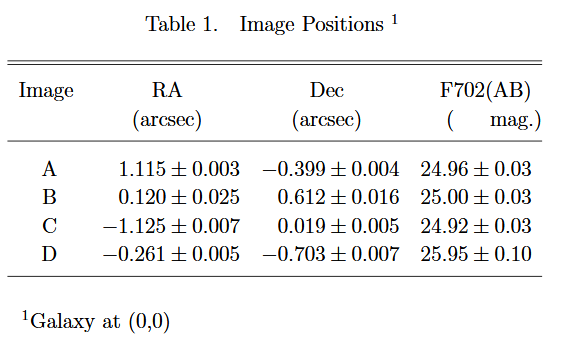

In [46]:
#> finding HST14113
hst = c[c['Name'].str.strip() == 'HST14113+5211'].copy()
hst[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RAJ2000_deg', 'DEJ2000_deg', 'dRA', 'dDEC', 'rpos', 'BibCode', 'BibCode2']]

,Name,Comp,RAJ2000,DEJ2000,RAJ2000_deg,DEJ2000_deg,dRA,dDEC,rpos,BibCode,BibCode2
120,HST14113+5211,A,14 11 19.7900,+52 11 29.900,212.832458,52.191639,1.103440,-0.1,Publication,1998ApJ...503L.127F,NaN
121,HST14113+5211,B,14 11 19.6900,+52 11 30.600,212.832042,52.191833,0.183906,0.6,Publication,1998ApJ...503L.127F,NaN
122,HST14113+5211,C,14 11 19.5400,+52 11 30.300,212.831417,52.191750,-1.195391,0.3,Publication,1998ApJ...503L.127F,NaN
123,HST14113+5211,D,14 11 19.6400,+52 11 29.300,212.831833,52.191472,-0.275861,-0.7,Publication,1998ApJ...503L.127F,NaN
124,HST14113+5211,G,14 11 19.6700,+52 11 30.000,212.831958,52.191667,0.000000,0.0,Publication,1998ApJ...503L.127F,NaN


In [47]:
#> adding 1998 Fischer values
hst['dRA_98F'] =  [1.115, 0.120, -1.125, -0.261, 0.0]
hst['dDEC_98F'] = [-0.399, 0.612, 0.019, -0.703, 0.0]
hst['dRA_diff'] = hst['dRA'] - hst['dRA_98F']
hst['dDEC_diff'] = hst['dDEC'] - hst['dDEC_98F']

hst[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RAJ2000_deg', 'DEJ2000_deg', 'dRA', 'dRA_98F', 'dRA_diff', 'dDEC', 'dDEC_98F', 'dDEC_diff']]

,Name,Comp,RAJ2000,DEJ2000,RAJ2000_deg,DEJ2000_deg,dRA,dRA_98F,dRA_diff,dDEC,dDEC_98F,dDEC_diff
120,HST14113+5211,A,14 11 19.7900,+52 11 29.900,212.832458,52.191639,1.103440,1.115,-0.011560,-0.1,-0.399,0.299
121,HST14113+5211,B,14 11 19.6900,+52 11 30.600,212.832042,52.191833,0.183906,0.120,0.063906,0.6,0.612,-0.012
122,HST14113+5211,C,14 11 19.5400,+52 11 30.300,212.831417,52.191750,-1.195391,-1.125,-0.070391,0.3,0.019,0.281
123,HST14113+5211,D,14 11 19.6400,+52 11 29.300,212.831833,52.191472,-0.275861,-0.261,-0.014861,-0.7,-0.703,0.003
124,HST14113+5211,G,14 11 19.6700,+52 11 30.000,212.831958,52.191667,0.000000,0.000,0.000000,0.0,0.000,0.000


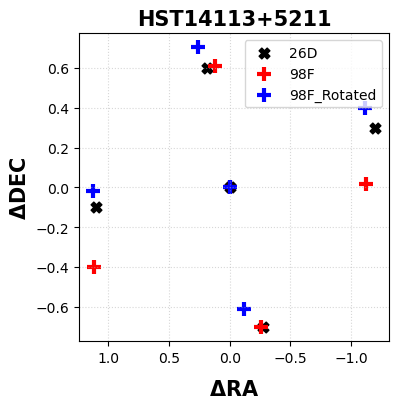

In [48]:
#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.grid(ls=':', alpha=0.5)
ax.set_title(hst['Name'].to_numpy()[0].strip(' '), fontweight='bold', fontsize=15)
ax.set_xlabel(r'$\mathbf{\Delta RA}$', fontsize=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\Delta DEC}$', fontsize=15)

#> plotting!
ax.scatter(hst['dRA'], hst['dDEC'], s=60, c='k', lw=1, marker='X', label='26D')
ax.scatter(hst['dRA_98F'], hst['dDEC_98F'], s=100, c='r', lw=3, marker='+', label='98F')
ax.scatter(-hst['dRA_98F'], -hst['dDEC_98F'], s=100, c='b', lw=3, marker='+', label='98F_Rotated')
ax.invert_xaxis()

plt.legend()
plt.show(); plt.close()

From Figure D.1. from 2026 Ducourant et al. \
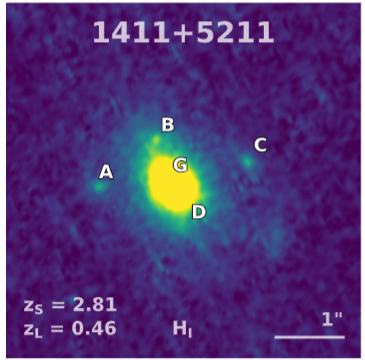 \
From the cutout above, the 26D image positions do appear more accurate!

However, taking the cut-out from 1998 Fischer, 98F seems more accurate. \
Note that for both cut-outs North is up and East is to the left. \
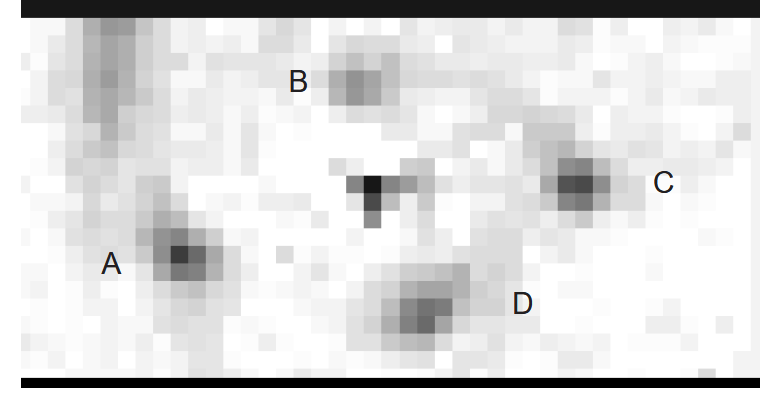

As a note, if one were to plot ax.scatter(-x, -y) for 98F (or a 180 degree rotation around 0,0), then there appears to just be a systematic offset between 98F and 26D. Both of the figure cut-outs state that North is up and East is to the left, however, the configurations do appear to be different. Plus, the nearby faint, source of light in the bottom left of 26D appears in the top right of 98F, consistent with a 180 degree rotation. 

In [49]:
hst[['Name', 'Comp', 'RAJ2000', 'DEJ2000']]

,Name,Comp,RAJ2000,DEJ2000
120,HST14113+5211,A,14 11 19.7900,+52 11 29.900
121,HST14113+5211,B,14 11 19.6900,+52 11 30.600
122,HST14113+5211,C,14 11 19.5400,+52 11 30.300
123,HST14113+5211,D,14 11 19.6400,+52 11 29.300
124,HST14113+5211,G,14 11 19.6700,+52 11 30.000


The [1998 Fischer et al.](https://ui.adsabs.harvard.edu/abs/1998ApJ...503L.127F) paper includes a [SIMBAD data product](https://simbad.u-strasbg.fr/simbad/sim-ref?querymethod=bib&simbo=on&submit=submit+bibcode&bibcode=1998ApJ...503L.127F), which does contain the absolute RA and DEC of images A-D. If '[WZA2016] hst14113 10 212.83200+52.19163' is supposed to be the deflector, then the system's configuration is way off. See the plotting tool in SIMBAD. Regardless, the RAJ2000 and DEJ2000 are similar for images A-D, but do not appear to be the same. However, this difference is likely due to SIMBAD as it would be similarly incorrect with the 1998 Fischer paper itself.

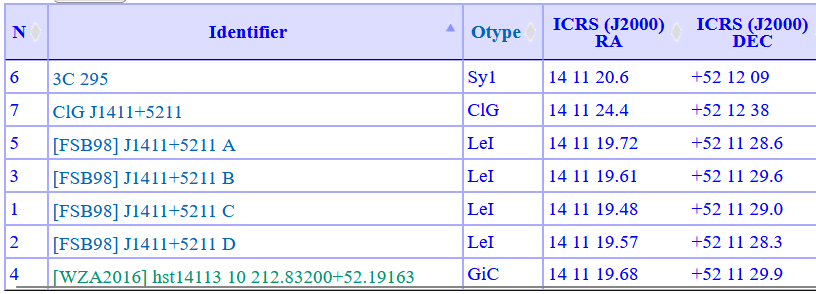

## ***B1608+656***

---

The original publication cited in the table is [1995 Myers et al.](https://articles.adsabs.harvard.edu/pdf/1995ApJ...447L...5M)
On page 6 (L7), Table 2 reports the relative image positions (and a way to obtain the absolute positions):

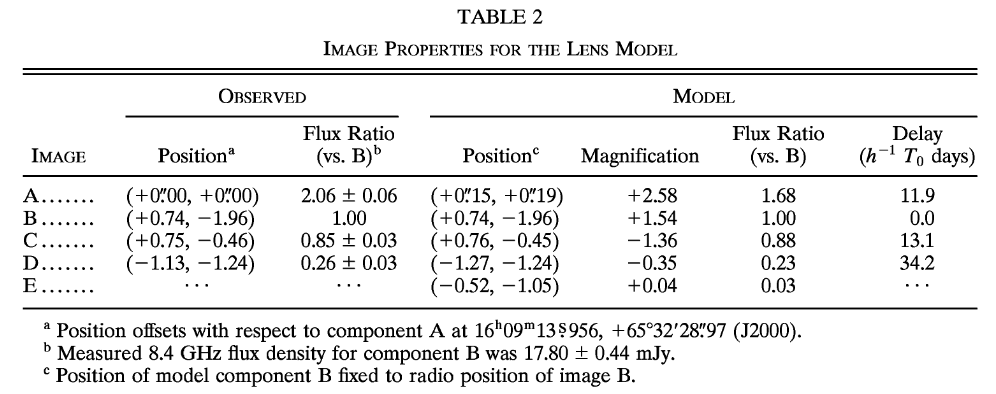

In [50]:
#> finding B1608+656
b = c[c['Name'].str.strip() == 'B1608+656'].copy()
b = b[ b['Comp'] != 'G ' ]

#> re-adjusting to image A
a_ref = b[ b['Comp'] == 'A ' ][['Name', 'dRA', 'dDEC']]
a_ref = a_ref.rename(columns={'dRA': 'dRA_A', 'dDEC': 'dDEC_A'})
b = b.merge(a_ref, how='left', on='Name')
b['dRA'] -= b['dRA_A']
b['dDEC'] -= b['dDEC_A']

b[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RAJ2000_deg', 'DEJ2000_deg', 'dRA', 'dDEC', 'rpos', 'BibCode', 'BibCode2']]

,Name,Comp,RAJ2000,DEJ2000,RAJ2000_deg,DEJ2000_deg,dRA,dDEC,rpos,BibCode,BibCode2
0,B1608+656,A,16 09 13.9861,+65 32 28.884,242.308275,65.541357,0.000000,0.000,Publication,1995ApJ...447L...5M,NaN
1,B1608+656,B,16 09 14.0749,+65 32 27.037,242.308645,65.540844,0.551514,-1.847,Publication,1995ApJ...447L...5M,NaN
2,B1608+656,C,16 09 14.0759,+65 32 28.546,242.308650,65.541263,0.557710,-0.338,Publication,1995ApJ...447L...5M,NaN
3,B1608+656,D,16 09 13.7741,+65 32 27.742,242.307392,65.541039,-1.316647,-1.142,Publication,1995ApJ...447L...5M,NaN


In [51]:
#> adding 1995 Myers values
b['dRA_95M'] =  [0.0, 0.74, 0.75, -1.13]
b['dDEC_95M'] = [0.0, -1.96, -0.46, -1.24]
b['dRA_diff'] = b['dRA'] - b['dRA_95M']
b['dDEC_diff'] = b['dDEC'] - b['dDEC_95M']

b[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RAJ2000_deg', 'DEJ2000_deg', 'dRA', 'dRA_95M', 'dRA_diff', 'dDEC', 'dDEC_95M', 'dDEC_diff']]

,Name,Comp,RAJ2000,DEJ2000,RAJ2000_deg,DEJ2000_deg,dRA,dRA_95M,dRA_diff,dDEC,dDEC_95M,dDEC_diff
0,B1608+656,A,16 09 13.9861,+65 32 28.884,242.308275,65.541357,0.000000,0.00,0.000000,0.000,0.00,0.000
1,B1608+656,B,16 09 14.0749,+65 32 27.037,242.308645,65.540844,0.551514,0.74,-0.188486,-1.847,-1.96,0.113
2,B1608+656,C,16 09 14.0759,+65 32 28.546,242.308650,65.541263,0.557710,0.75,-0.192290,-0.338,-0.46,0.122
3,B1608+656,D,16 09 13.7741,+65 32 27.742,242.307392,65.541039,-1.316647,-1.13,-0.186647,-1.142,-1.24,0.098


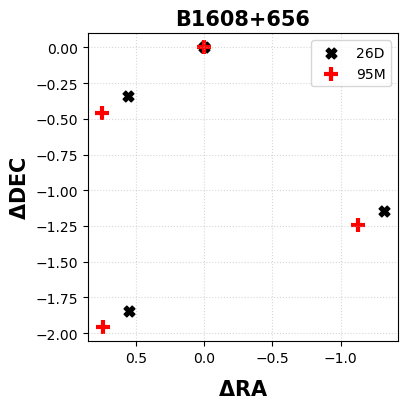

In [52]:
#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.grid(ls=':', alpha=0.5)
ax.set_title(b['Name'].to_numpy()[0].strip(' '), fontweight='bold', fontsize=15)
ax.set_xlabel(r'$\mathbf{\Delta RA}$', fontsize=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\Delta DEC}$', fontsize=15)

#> plotting!
ax.scatter(b['dRA'], b['dDEC'], s=60, c='k', lw=1, marker='X', label='26D')
ax.scatter(b['dRA_95M'], b['dDEC_95M'], s=100, c='r', lw=3, marker='+', label='95M')
ax.invert_xaxis()

plt.legend()
plt.show(); plt.close()

From Figure D.1 from 2026 Ducourant et al. \
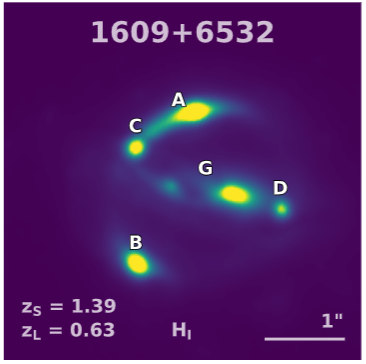

In [53]:
#> getting the galaxy position again
b_ = c[c['Name'].str.strip() == 'B1608+656'].copy()
b_[['Name', 'Comp', 'RAJ2000', 'DEJ2000']]

,Name,Comp,RAJ2000,DEJ2000
30,B1608+656,A,16 09 13.9861,+65 32 28.884
31,B1608+656,B,16 09 14.0749,+65 32 27.037
32,B1608+656,C,16 09 14.0759,+65 32 28.546
33,B1608+656,D,16 09 13.7741,+65 32 27.742
34,B1608+656,G,16 09 13.9300,+65 32 28.000


The [1995 Myers et al.](https://ui.adsabs.harvard.edu/abs/1995ApJ...447L...5M/abstract) paper does include a [SIMBAD data product](https://simbad.u-strasbg.fr/simbad/sim-ref?querymethod=bib&simbo=on&submit=submit+bibcode&bibcode=1995ApJ...447L...5M), which does contain the positions of all components A-D and G. The XXJ2000 of images B, C, and D are consistent with SIMBAD. However, Image A and the galaxy position do not match. Again, this could be an issue with SIMBAD as the configuration of the lens, as seen from SIMBAD, does not appear to be correct due to the positions of A and G.

Images B, C, and D all appear to have similar offsets 26D-95M offsets, and thus image A could be the cause here.

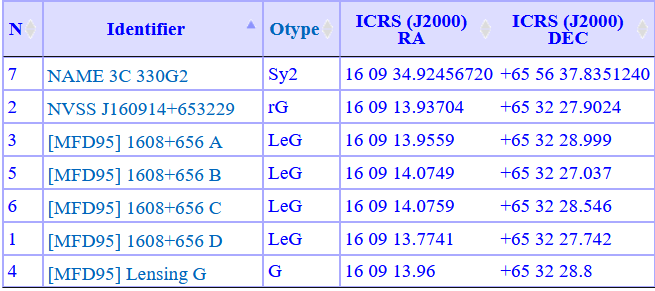

## ***B1555+375***

---

The original publication cited in the table is [1999 Marlow et al.](https://ui.adsabs.harvard.edu/abs/1999AJ....118..654M)
There are image positions for the two radio frequency bands 5 GHz and 15 GHz:

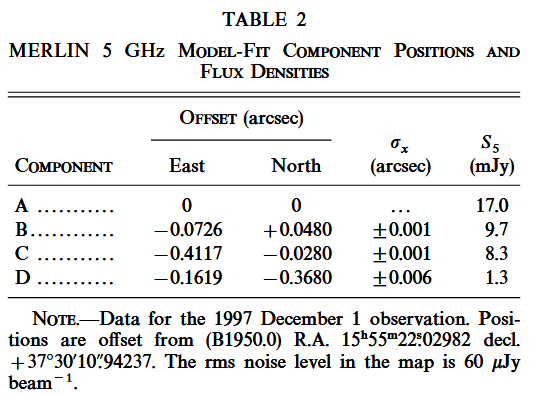 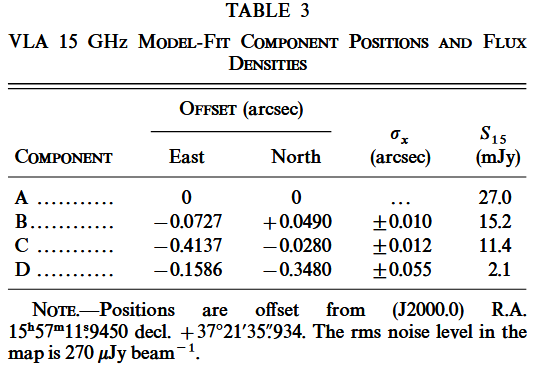

In [54]:
#> finding B1555+375
b1555 = c[c['Name'].str.strip() == 'B1555+375'].copy()
b1555 = b1555[ b1555['Comp'] != 'G ' ]

#> re-adjusting to image A
a_ref = b1555[ b1555['Comp'] == 'A ' ][['Name', 'dRA', 'dDEC']]
a_ref = a_ref.rename(columns={'dRA': 'dRA_A', 'dDEC': 'dDEC_A'})
b1555 = b1555.merge(a_ref, how='left', on='Name')
b1555['dRA'] -= b1555['dRA_A']
b1555['dDEC'] -= b1555['dDEC_A']

b1555[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RAJ2000_deg', 'DEJ2000_deg', 'dRA', 'dDEC', 'rpos', 'BibCode', 'BibCode2']]

,Name,Comp,RAJ2000,DEJ2000,RAJ2000_deg,DEJ2000_deg,dRA,dDEC,rpos,BibCode,BibCode2
0,B1555+375,A,15 57 11.9450,+37 21 35.934,239.299771,37.359982,0.000000,0.000,Publication,1999AJ....118..654M,NaN
1,B1555+375,B,15 57 11.9389,+37 21 35.983,239.299745,37.359995,-0.072728,0.049,Publication,1999AJ....118..654M,NaN
2,B1555+375,C,15 57 11.9103,+37 21 35.906,239.299626,37.359974,-0.413714,-0.028,Publication,1999AJ....118..654M,NaN
3,B1555+375,D,15 57 11.9317,+37 21 35.586,239.299715,37.359885,-0.158570,-0.348,Publication,1999AJ....118..654M,NaN


When compared to the tables above, the 15 GHz image positions match quite well. Thus, that is what I will be using from here on for comparisons.

In [55]:
#> adding 1999 Marlow values
b1555['dRA_99M'] =  [0.0, -0.0727, -0.4137, -0.1586]
b1555['dDEC_99M'] = [0.0, 0.0490, -0.0280, -0.3480]
b1555['dRA_diff'] = b1555['dRA'] - b1555['dRA_99M']
b1555['dDEC_diff'] = b1555['dDEC'] - b1555['dDEC_99M']

b1555[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RAJ2000_deg', 'DEJ2000_deg', 'dRA', 'dRA_99M', 'dRA_diff', 'dDEC', 'dDEC_99M', 'dDEC_diff']]

,Name,Comp,RAJ2000,DEJ2000,RAJ2000_deg,DEJ2000_deg,dRA,dRA_99M,dRA_diff,dDEC,dDEC_99M,dDEC_diff
0,B1555+375,A,15 57 11.9450,+37 21 35.934,239.299771,37.359982,0.000000,0.0000,0.000000,0.000,0.000,0.000000e+00
1,B1555+375,B,15 57 11.9389,+37 21 35.983,239.299745,37.359995,-0.072728,-0.0727,-0.000028,0.049,0.049,-1.286844e-11
2,B1555+375,C,15 57 11.9103,+37 21 35.906,239.299626,37.359974,-0.413714,-0.4137,-0.000014,-0.028,-0.028,-1.457192e-11
3,B1555+375,D,15 57 11.9317,+37 21 35.586,239.299715,37.359885,-0.158570,-0.1586,0.000030,-0.348,-0.348,-1.666833e-11


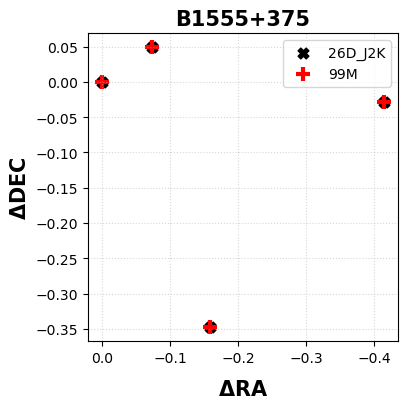

In [56]:
#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.grid(ls=':', alpha=0.5)
ax.set_title(b1555['Name'].to_numpy()[0].strip(' '), fontweight='bold', fontsize=15)
ax.set_xlabel(r'$\mathbf{\Delta RA}$', fontsize=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\Delta DEC}$', fontsize=15)

#> plotting!
ax.scatter(b1555['dRA'], b1555['dDEC'], s=60, c='k', lw=1, marker='X', label='26D_J2K')
ax.scatter(b1555['dRA_99M'], b1555['dDEC_99M'], s=100, c='r', lw=3, marker='+', label='99M')
ax.invert_xaxis()

plt.legend()
plt.show(); plt.close()

The 15 GHz observations match XXJ2000 well! But why is there a huge difference between the 'best coords' (XXJ2000) and Publication (XXpdeg)?

How does the relative image positions of XXpdeg compare?

In [57]:
#> getting galaxies
A_ref = b1555[ b1555['Comp'] == 'A ' ][['Name', 'RApdeg', 'DEpdeg']]
A_ref = A_ref.rename(columns={'RApdeg': 'RA_A_deg', 'DEpdeg': 'DE_A_deg'})

#> merging G
b1555_ = b1555.merge(A_ref, how='left', on='Name')

#> relative RA and DEC
b1555_['dRA_pdeg'] = (b1555_['RApdeg'] - b1555_['RA_A_deg']) * np.cos(np.deg2rad(b1555_['DEpdeg'])) * 3600 # delta RA * cos(dec)
b1555_['dDEC_pdeg'] = (b1555_['DEpdeg'] - b1555_['DE_A_deg']) * 3600 # delta dec
b1555_['dRA_diff'] = b1555_['dRA'] - b1555_['dRA_pdeg']
b1555_['dDEC_diff'] = b1555_['dDEC'] - b1555_['dDEC_pdeg']
b1555_[['Name', 'Comp', 'dRA', 'dRA_pdeg', 'dRA_diff', 'dDEC', 'dDEC_pdeg', 'dDEC_diff']]

,Name,Comp,dRA,dRA_pdeg,dRA_diff,dDEC,dDEC_pdeg,dDEC_diff
0,B1555+375,A,0.000000,0.000000,0.000000,0.000,0.0,0.000
1,B1555+375,B,-0.072728,-0.119226,0.046498,0.049,0.0,0.049
2,B1555+375,C,-0.413714,-0.357677,-0.056036,-0.028,-0.1,0.072
3,B1555+375,D,-0.158570,-0.119226,-0.039344,-0.348,-0.4,0.052


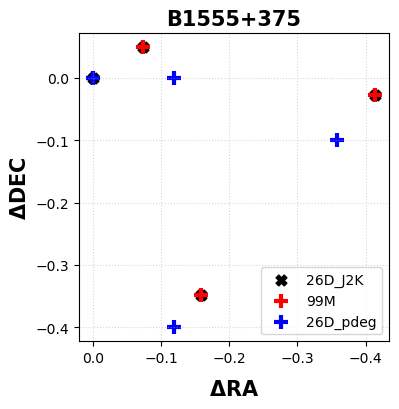

In [58]:
#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.grid(ls=':', alpha=0.5)
ax.set_title(b1555_['Name'].to_numpy()[0].strip(' '), fontweight='bold', fontsize=15)
ax.set_xlabel(r'$\mathbf{\Delta RA}$', fontsize=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\Delta DEC}$', fontsize=15)

#> plotting!
ax.scatter(b1555_['dRA'], b1555_['dDEC'], s=60, c='k', lw=1, marker='X', label='26D_J2K')
ax.scatter(b1555_['dRA_99M'], b1555_['dDEC_99M'], s=100, c='r', lw=3, marker='+', label='99M')
ax.scatter(b1555_['dRA_pdeg'], b1555_['dDEC_pdeg'], s=100, c='b', lw=3, marker='+', label='26D_pdeg')
ax.invert_xaxis()

plt.legend()
plt.show(); plt.close()

The relative image positions calculated from XXpdeg do not match either 5 or 15 GHz observation.

In [59]:
#> getting the galaxy back
b1555_[['Name', 'Comp', 'RAJ2000', 'DEJ2000', 'RApdeg', 'DEpdeg']]

,Name,Comp,RAJ2000,DEJ2000,RApdeg,DEpdeg
0,B1555+375,A,15 57 11.9450,+37 21 35.934,239.299750,37.360000
1,B1555+375,B,15 57 11.9389,+37 21 35.983,239.299708,37.360000
2,B1555+375,C,15 57 11.9103,+37 21 35.906,239.299625,37.359972
3,B1555+375,D,15 57 11.9317,+37 21 35.586,239.299708,37.359889


The [1999 Marlow et al.](https://ui.adsabs.harvard.edu/abs/1999AJ....118..654M/abstract) paper does contain a [SIMBAD data product](https://simbad.u-strasbg.fr/simbad/sim-ref?querymethod=bib&simbo=on&submit=submit+bibcode&bibcode=1999AJ....118..654M), which does contain all components A-D. The top could be the center of the lensing galaxy, but I do not believe it is. The XXpdeg from 26D do match closely the image positions given by SIMBAD.

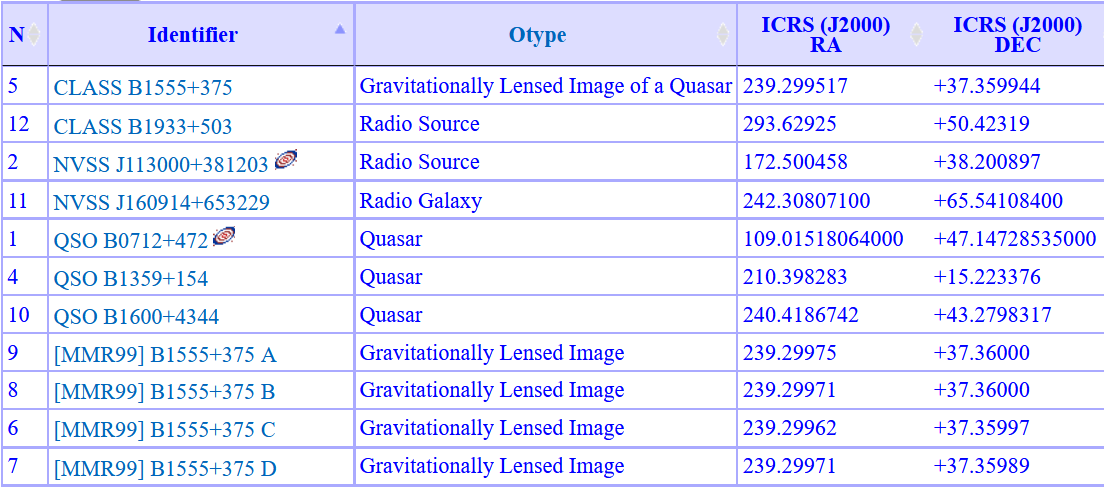

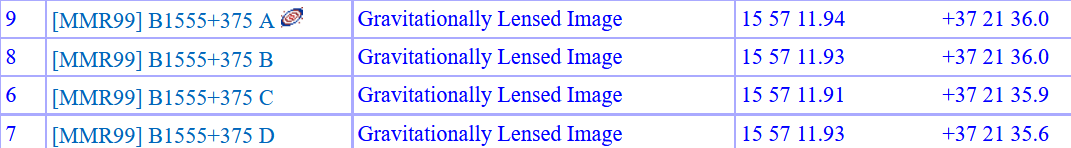